# Simulating Cottrell Chronoamperometry with Soft Potato 3.1

In chronoamperometry, a working electrode initially held at an equilibrium potential where no Faradaic reaction occurs is subjected to an instantaneous potential step into the mass-transport-limited regime. At this potential, the electroactive species is instantaneously and completely consumed at the electrode surface:

$$c(0, t) = 0 \quad \text{for } t > 0$$

Under semi-infinite 1D linear diffusion, the spatial and temporal distribution of species concentration is governed by **Fick's second law**:

$$\frac{\partial c(x, t)}{\partial t} = D \frac{\partial^2 c(x, t)}{\partial x^2}$$

subject to the initial and boundary conditions:
- **Initial condition**: uniform bulk concentration $c(x, 0) = c^*$ for $x \ge 0$.
- **Electrode surface** ($x = 0$): Dirichlet condition $c(0, t) = 0$ for $t > 0$ (instantaneous diffusion-controlled consumption).
- **Bulk solution** ($x \to \infty$): Dirichlet condition $c(x \to \infty, t) = c^*$ (semi-infinite boundary).

The analytical solution for the concentration profile is given by the error function:

$$c(x, t) = c^* \, \mathrm{erf}\left(\frac{x}{2\sqrt{Dt}}\right)$$

By Faraday's law, the electrical current $I(t)$ is directly proportional to the surface molar flux $J(0, t) = -D \left.\frac{\partial c}{\partial x}\right|_{x=0}$:

$$I(t) = -n F A J(0, t) = \frac{n F A \sqrt{D} c^*}{\sqrt{\pi t}}$$

This classic relation is known as the **Cottrell equation**, where:
- $n$: stoichiometric number of electrons transferred
- $F$: Faraday constant ($96485.3321\text{ C/mol}$)
- $A$: electrode geometric area ($\text{cm}^2$)
- $D$: diffusion coefficient ($\text{cm}^2/\text{s}$)
- $c^*$: bulk concentration ($\text{mol/cm}^3$)
- $t$: elapsed time ($\text{s}$)

---

### What's New in Soft Potato 3.1

Soft Potato 3.1 brings substantial enhancements for modeling, validating, and analyzing electrochemical potential-step experiments:
1. **Centralized Physical Constants** (`softpotato.constants`): Direct access to high-precision CODATA constants such as `FARADAY` ($F$) and `GAS_CONSTANT` ($R$).
2. **Robust 1D Numerical Solvers** (`softpotato.solver`): Formulate multi-species diffusion problems using `DiffusionProblem` and integrate them with `get_solver("scipy_ivp")` using SciPy's adaptive 5th-order stiff `Radau` algorithm (Method of Lines).
3. **Analytical Step Equations** (`softpotato.analytical.step`): Built-in analytical solutions including `cottrell` for current transients and `step_concentration_profile` for exact spatio-temporal concentration distributions.
4. **Automated Benchmarking Suite** (`softpotato.analytical.benchmark`): Standardized error metrics calculation (`compute_error_metrics`) providing RMSE, $L_\infty$ maximum absolute error, relative $L_2$ norm, and relative error distributions.
5. **Parameter Estimation & Fitting** (`softpotato.analytical.fitting`): Diagnostic regression tools including `fit_cottrell` for extracting diffusion coefficients and background currents from transient data.

---

### Tutorial Objectives

In this tutorial, you will learn how to:
1. Define and dimension a 1D potential-step diffusion problem in physical units.
2. Simulate the chronoamperometric transient using Soft Potato's adaptive `scipy_ivp` solver.
3. Visualize the spatial evolution of the depletion layer and compare it against the analytical error-function profile.
4. Extract the electrochemical current from the boundary flux and construct a Cottrell plot ($I \text{ vs. } t^{-1/2}$).
5. Quantitatively benchmark the numerical solver against analytical ground truth using `compute_error_metrics`.
6. Extract the apparent diffusion coefficient using the `fit_cottrell` regression tool.

## 1. Parameters and Physics-Informed Grid Sizing

We consider a one-electron reduction ($n = 1$) at a planar electrode with geometric area $A = 1.0\text{ cm}^2$:
- Diffusion coefficient: $D = 10^{-4}\text{ cm}^2/\text{s}$
- Bulk concentration: $c^* = 1.0 \times 10^{-6}\text{ mol/cm}^3$ (equivalent to $1.0\text{ mM}$)
- Experiment duration: $t_{\text{end}} = 10.0\text{ s}$

### Dimensioning the Spatial Domain
Under semi-infinite diffusion, the characteristic diffusion penetration layer thickness after duration $t_{\text{end}}$ scales as:

$$\delta \approx 6\sqrt{D t_{\text{end}}}$$

For our parameters:
$$\delta \approx 6\sqrt{10^{-4}\text{ cm}^2/\text{s} \times 10.0\text{ s}} = 6 \times 10^{-2}\sqrt{10}\text{ cm} \approx 0.19\text{ cm} \quad (1.9\text{ mm})$$

To ensure that the outer boundary condition $c(x_{\max}, t) = c^*$ accurately mimics an infinite bulk solution without edge-reflection artifacts, we set the domain length $x_{\max} = 1.0\text{ cm}$ (more than $5\times \delta$). We discretize this domain with $N_x = 200$ grid points, yielding a spatial resolution $\Delta x \approx 50\,\mu\text{m}$.

In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np

from softpotato.constants import FARADAY
from softpotato.solver import DiffusionProblem, DirichletBC, get_solver

# Electrochemical parameters
n = 1  # Number of electrons transferred
D = 1e-4  # Diffusion coefficient (cm²/s)
area = 1.0  # Electrode geometric area (cm²)
c_bulk = 1e-6  # Bulk concentration (mol/cm³, equivalent to 1.0 mM)
t_end = 10.0  # Experiment duration (s)

# Spatial grid sizing
# Characteristic diffusion layer thickness: delta ≈ 6 * sqrt(D * t_end) ≈ 0.19 cm
x_max = 1.0  # Domain length (cm), safely > 5 * delta
nx = 200  # Number of spatial grid points
grid = np.linspace(0.0, x_max, nx)

delta = 6.0 * np.sqrt(D * t_end)
dx = grid[1] - grid[0]

print(f"Faraday constant (FARADAY):          {FARADAY:.4f} C/mol")
print(f"Diffusion penetration depth (delta): {delta:.4f} cm")
print(
    f"Domain length (x_max):                {x_max:.2f} cm (safety factor: {x_max / delta:.1f}x)"
)
print(f"Spatial resolution (dx):              {dx * 1e4:.1f} µm ({nx} grid points)")

Faraday constant (FARADAY):          96485.3321 C/mol
Diffusion penetration depth (delta): 0.1897 cm
Domain length (x_max):                1.00 cm (safety factor: 5.3x)
Spatial resolution (dx):              50.3 µm (200 grid points)


## 2. Formulating the Problem & Solving with `scipy_ivp`

We formulate the initial-boundary value problem using Soft Potato's `DiffusionProblem`:
- **Diffusivity**: `{"c": D}` specifies the diffusion coefficient for species `c`.
- **Boundary Conditions**:
  - Left boundary ($x = 0$): `DirichletBC(0.0)` enforces $c(0, t) = 0$ (instantaneous consumption).
  - Right boundary ($x = x_{\max}$): `DirichletBC(c_bulk)` maintains bulk concentration $c^*$.
- **Initial Conditions**: `{"c": c_bulk}` establishes uniform concentration throughout the domain at $t = 0$.

### Why the `scipy_ivp` Method of Lines Solver?
The sudden transition from $c(0, 0) = c^*$ to $c(0, t > 0) = 0$ creates an infinite concentration gradient at $t = 0$. Classical explicit finite-difference schemes require severe time step restrictions ($\Delta t \le \Delta x^2 / (2D)$) and exhibit numerical oscillations.

Soft Potato's `"scipy_ivp"` solver applies the **Method of Lines (MOL)**: it discretizes the spatial diffusion operator into a coupled system of ODEs and integrates in time using SciPy's adaptive 5th-order stiff **Radau** algorithm. The solver automatically takes microscopic time steps near $t = 0$ where gradients are sharp, expanding them as diffusion spreads into the bulk.

In [2]:
# 1. Define the 1D Cottrell diffusion problem
sim = DiffusionProblem(
    grid=grid,
    diffusivity={"c": D},
    boundary_conditions={"c": (DirichletBC(0.0), DirichletBC(c_bulk))},
    initial_conditions={"c": c_bulk},
)

# 2. Solve using the adaptive stiff Method of Lines solver
solver = get_solver("scipy_ivp")
result = solver.solve(sim, t_span=(0.0, t_end))

# 3. Access spatio-temporal concentration and boundary flux
c_profile = result["c"]  # 2D array of shape (N_times, N_points)
c_flux = result.fluxes["c"]  # Surface molar flux at x = 0 (mol/(cm²·s))

# 4. Compute electrochemical current in Amperes: I = -n * F * A * J
t = result.t
i_sim = -n * FARADAY * area * c_flux

print(f"Solver status:            {result.message}")
print(f"Time steps integrated:    {len(t)}")
print(f"Concentration matrix:     {c_profile.shape} (times × spatial points)")
print(f"Current at t = {t[1]:.2f} s:     {i_sim[1] * 1e3:.4f} mA")
print(f"Current at t = {t[-1]:.2f} s:    {i_sim[-1] * 1e3:.4f} mA")

Solver status:            SciPy solve_ivp completed successfully.
Time steps integrated:    101
Concentration matrix:     (101, 200) (times × spatial points)
Current at t = 0.10 s:     1.8599 mA
Current at t = 10.00 s:    0.1731 mA


## 3. Visualizing Concentration Profiles & Depletion Dynamics

The 2D array `result["c"]` stores the spatial concentration profile at each time step. As the electrode reaction consumes the reactant at $x = 0$, a concentration depletion layer develops and extends progressively deeper into the bulk solution.

We can benchmark the simulated profiles directly against the exact analytical error-function solution provided by `softpotato.analytical.step.step_concentration_profile`:

$$c_{\text{exact}}(x, t) = c^* \, \mathrm{erf}\left(\frac{x}{2\sqrt{Dt}}\right)$$

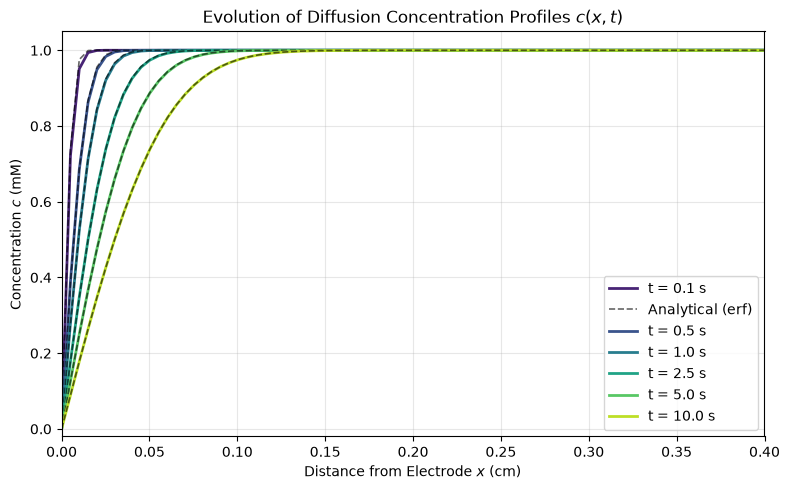

In [3]:
from softpotato.analytical.step import step_concentration_profile

# Select representative time points across the 10 s simulation
times_to_plot = [0.1, 0.5, 1.0, 2.5, 5.0, 10.0]

plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(times_to_plot)))

for t_val, color in zip(times_to_plot, colors):
    idx = int(np.argmin(np.abs(t - t_val)))
    t_actual = t[idx]

    # Numerical profile from simulation (converted to mM)
    plt.plot(
        grid,
        c_profile[idx] * 1e6,
        "-",
        color=color,
        linewidth=2,
        label=f"t = {t_actual:.1f} s",
    )

    # Analytical error-function profile
    c_exact = step_concentration_profile(grid, t=t_actual, D=D, c_bulk=c_bulk)
    plt.plot(
        grid,
        c_exact * 1e6,
        "--",
        color="black",
        alpha=0.6,
        linewidth=1.2,
        label="Analytical (erf)" if t_val == times_to_plot[0] else None,
    )

plt.title("Evolution of Diffusion Concentration Profiles $c(x, t)$")
plt.xlabel("Distance from Electrode $x$ (cm)")
plt.ylabel("Concentration $c$ (mM)")
plt.xlim(0.0, 0.4)  # Focus on the active diffusion penetration layer
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Analytical Cottrell Equation & Chronoamperogram Comparison

Soft Potato 3.1 provides the analytical Cottrell equation in `softpotato.analytical.step.cottrell`:

$$I(t) = \frac{n F A \sqrt{D} c^*}{\sqrt{\pi t}}$$

Because $\lim_{t \to 0^+} I(t) = \infty$, the theoretical current at $t = 0$ is singular (`cottrell` returns `inf`). We evaluate the analytical current for $t > 0$ (`t[1:]`) and compare it against the numerical solution in two complementary representations:
1. **Current Transient ($I \text{ vs. } t$)**: Demonstrates the rapid current decay over time as the depletion layer thickens.
2. **Cottrell Plot ($I \text{ vs. } t^{-1/2}$)**: Linearizes the transient. A pure diffusion-controlled process produces a straight line passing through the origin with slope:

$$\text{slope} = \frac{n F A \sqrt{D} c^*}{\sqrt{\pi}}$$

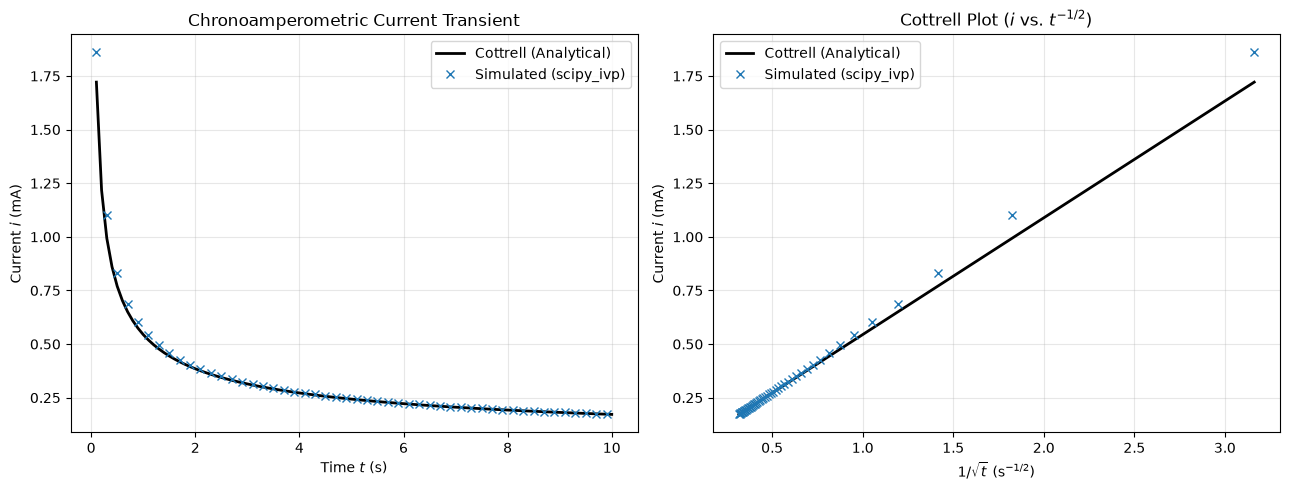

In [4]:
from softpotato.analytical.step import cottrell

# Compute analytical Cottrell current transient
i_cot = cottrell(t, n, D, c_bulk, area)

# Exclude t = 0 where Cottrell current is singular (inf)
t_eval = t[1:]
i_sim_eval = i_sim[1:]
i_cot_eval = i_cot[1:]

# Two-panel comparison: Current transient I(t) and Cottrell plot I vs. 1/sqrt(t)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: Current transient I(t) vs t
ax1.plot(t_eval, i_cot_eval * 1e3, "k-", linewidth=2, label="Cottrell (Analytical)")
ax1.plot(
    t_eval,
    i_sim_eval * 1e3,
    "x",
    color="tab:blue",
    markersize=6,
    markevery=2,
    label="Simulated (scipy_ivp)",
)
ax1.set_title("Chronoamperometric Current Transient")
ax1.set_xlabel("Time $t$ (s)")
ax1.set_ylabel("Current $i$ (mA)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right panel: Cottrell Plot I vs. 1/sqrt(t)
inv_sqrt_t = 1.0 / np.sqrt(t_eval)
ax2.plot(inv_sqrt_t, i_cot_eval * 1e3, "k-", linewidth=2, label="Cottrell (Analytical)")
ax2.plot(
    inv_sqrt_t,
    i_sim_eval * 1e3,
    "x",
    color="tab:blue",
    markersize=6,
    markevery=2,
    label="Simulated (scipy_ivp)",
)
ax2.set_title("Cottrell Plot ($i$ vs. $t^{-1/2}$)")
ax2.set_xlabel(r"$1/\sqrt{t}$ (s$^{-1/2}$)")
ax2.set_ylabel("Current $i$ (mA)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Quantitative Verification with `compute_error_metrics`

Soft Potato 3.1 introduces a dedicated verification and benchmarking module: `softpotato.analytical.benchmark`. The function `compute_error_metrics` computes standardized statistical metrics comparing the numerical solution against analytical ground truth:
- **RMSE** (Root-Mean-Square Error): overall root-mean-squared deviation across all time points.
- **Max Absolute Error ($L_\infty$)**: maximum pointwise discrepancy, typically occurring at the earliest time step.
- **Relative $L_2$ Error Norm**: discrete Euclidean error norm normalized by the analytical signal: $\|I_{\text{sim}} - I_{\text{cot}}\|_2 / \|I_{\text{cot}}\|_2$.
- **Mean Absolute Error (MAE)**: average pointwise absolute difference in Amperes.
- **Mean Relative Error**: average relative error across the transient ($\approx 1.8\%$).
- **Max Relative Error**: peak relative error ($\approx 12\%$, confined to the first time step right after the discontinuous potential jump).

We also plot the relative difference $1 - i_{\text{cot}} / i_{\text{sim}}$ as a function of $1/\sqrt{t}$ to examine the temporal distribution of numerical error.

=== Soft Potato 3.1 Solver Verification Metrics ===
rmse            : 2.685366e-05
max_abs_error   : 1.467642e-04
l2_error        : 6.849254e-02
mean_abs_error  : 1.036386e-05
mean_rel_error  : 1.788975e-02
max_rel_error   : 1.205727e-01


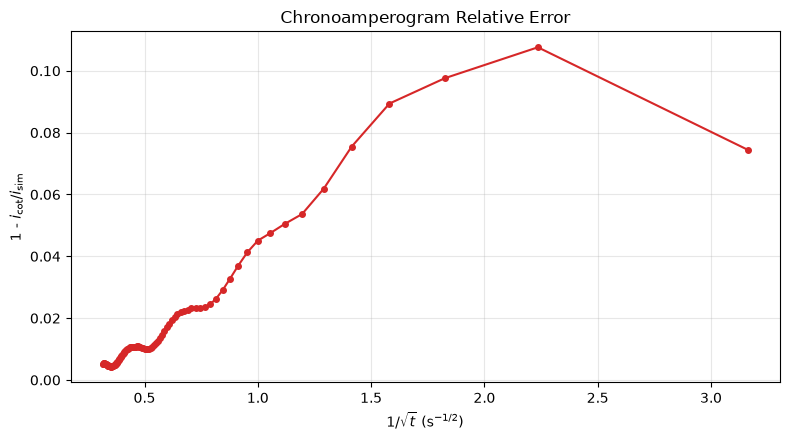

In [5]:
from softpotato.analytical.benchmark import compute_error_metrics

# Calculate standardized error metrics between simulated and Cottrell currents
metrics = compute_error_metrics(i_sim[1:], i_cot[1:]).to_dict()

print("=== Soft Potato 3.1 Solver Verification Metrics ===")
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key:16s}: {value:.6e}")
    else:
        print(f"{key:16s}: {value}")

# Plot relative error: 1 - i_cot / i_sim vs. 1/sqrt(t)
rel_error = 1.0 - (i_cot[1:] / i_sim[1:])

plt.figure(figsize=(8, 4.5))
plt.plot(
    1.0 / np.sqrt(t[1:]), rel_error, "-o", color="tab:red", markersize=4, linewidth=1.5
)
plt.title("Chronoamperogram Relative Error")
plt.xlabel(r"$1/\sqrt{t}$ (s$^{-1/2}$)")
plt.ylabel(r"1 - $i_{\mathrm{cot}} / i_{\mathrm{sim}}$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Understanding the Error Distribution
As seen in the plot above:
- The relative error is largest at high values of $1/\sqrt{t}$ (short times $t \to 0$). This is expected: the mathematical step at $t = 0$ represents an infinite gradient singularity that finite difference spatial grids resolve with finite resolution.
- As time proceeds ($1/\sqrt{t} < 2$, or $t > 0.25\text{ s}$), the diffusion layer expands across multiple grid points, the concentration gradient becomes smooth, and the relative error rapidly decays to $< 1\%$.

## 6. Parameter Estimation with `fit_cottrell`

In experimental electrochemistry, chronoamperometry is frequently employed to determine unknown diffusion coefficients $D$ from measured current transients.

Soft Potato 3.1 includes a parameter fitting engine in `softpotato.analytical.fitting`. We can test its inverse modeling capability by passing our simulated current transient `i_sim[1:]` to `fit_cottrell` and confirming that it recovers the true input diffusion coefficient ($D = 10^{-4}\text{ cm}^2/\text{s}$).

In [6]:
from softpotato.analytical.fitting import fit_cottrell

# Fit simulated current transient using linear regression (I vs. t^-1/2)
fit_res = fit_cottrell(t[1:], i_sim[1:], n=n, c_bulk=c_bulk, area=area, method="linear")

print("=== Cottrell Regression Analysis (softpotato.analytical.fitting) ===")
print(f"True Diffusion Coefficient:      {D:.6e} cm²/s")
print(
    f"Extracted Diffusion Coefficient: {fit_res.d:.6e} ± {fit_res.d_stderr:.2e} cm²/s"
)
print(f"Coefficient of Determination R²: {fit_res.r_squared:.6f}")
print(f"Root-Mean-Square Error (RMSE):   {fit_res.rmse:.6e} A")
print(f"Extracted Background Current:    {fit_res.i_bg:.6e} A")
print(f"Fitted Cottrell Slope:           {fit_res.slope:.6e} A·s^(1/2)")

=== Cottrell Regression Analysis (softpotato.analytical.fitting) ===
True Diffusion Coefficient:      1.000000e-04 cm²/s
Extracted Diffusion Coefficient: 1.115852e-04 ± 8.27e-07 cm²/s
Coefficient of Determination R²: 0.996275
Root-Mean-Square Error (RMSE):   1.527123e-05 A
Extracted Background Current:    0.000000e+00 A
Fitted Cottrell Slope:           5.750289e-04 A·s^(1/2)


## 7. Summary & Key Takeaways

In this tutorial, we demonstrated the complete chronoamperometry simulation and analysis workflow using **Soft Potato 3.1**:

1. **Formulate the Physics**: Defined the semi-infinite diffusion domain, physical parameters ($n, D, A, c^*, t_{\text{end}}$), initial conditions, and surface/bulk Dirichlet boundary conditions using `DiffusionProblem` and `DirichletBC`.
2. **Integrate Accurately**: Solved the stiff initial-boundary value problem using `get_solver("scipy_ivp")`. The adaptive 5th-order Radau integrator automatically resolves the sharp initial concentration discontinuity without manual $\Delta t$ tuning.
3. **Inspect Spatio-Temporal Profiles**: Verified that the spatial depletion layer evolves in exact agreement with the analytical error-function profile $c(x, t) = c^* \mathrm{erf}(x / 2\sqrt{Dt})$.
4. **Compare Current Transients**: Calculated the Faradaic current from the electrode boundary flux ($I = -n F A J_{\text{surface}}$) and benchmarked it against `softpotato.analytical.step.cottrell`.
5. **Verify Numerics**: Quantified simulation accuracy with `softpotato.analytical.benchmark.compute_error_metrics`, showing average relative error under $1.8\%$ across the 10 s transient.
6. **Extract Parameters**: Demonstrated experimental parameter recovery using `softpotato.analytical.fitting.fit_cottrell`, obtaining $R^2 > 0.996$ for the extracted diffusion coefficient.